In [9]:
import json
import os
from openai import OpenAI
import openai
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
def get_embedding(text, client, model="text-embedding-3-small"):
    response = client.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding

In [ ]:
# os.environ["OPENAI_API_KEY"] =
client = OpenAI()
persona_idea_files = [f'ai_scientist_persona_baseline_ideas{i}.json' for i in ['', 2, 3]]
persona_idea_sets = []
for persona_idea_file in persona_idea_files:
    with open(os.path.join('templates/ppo_with_folds', persona_idea_file), 'r') as f:
        ideas = json.load(f)
        persona_idea_sets.append(ideas)

In [4]:
seed_ideas = ['fold_specific_learning_rates', 'input_dependent_hyperplane_combination']
exp_embeddings = np.array([[get_embedding(idea["Experiment"], client) for idea in ideas if idea["Name"] not in seed_ideas] for ideas in persona_idea_sets])
persona_embeddings = np.array([[get_embedding(idea["Persona"], client) for idea in ideas if idea["Name"] not in seed_ideas] for ideas in persona_idea_sets])

In [6]:
exp_similarities_between_sets = []
persona_similarities_between_sets = []
for i in range(len(persona_idea_sets)):
    for j in range(i+1, len(persona_idea_sets)):
        exp_similarities_between_sets.extend(cosine_similarity(exp_embeddings[i], exp_embeddings[j]).flatten())
        persona_similarities_between_sets.extend(cosine_similarity(persona_embeddings[i], persona_embeddings[j]).flatten())
baseline_similarities_between_sets = np.array(exp_similarities_between_sets)
persona_similarities_between_sets = np.array(persona_similarities_between_sets)
baseline_similarities_within_sets = []
persona_similarities_within_sets = []
for i in range(len(persona_idea_sets)):
    baseline_similarities = cosine_similarity(exp_embeddings[i], exp_embeddings[i])
    upper_triangle_indices = np.triu_indices(baseline_similarities.shape[0], k=1)
    upper_triangle_values = baseline_similarities[upper_triangle_indices]
    baseline_similarities_within_sets.extend(upper_triangle_values)
    persona_similarities = cosine_similarity(persona_embeddings[i], persona_embeddings[i])
    upper_triangle_indices = np.triu_indices(persona_similarities.shape[0], k=1)
    upper_triangle_values = persona_similarities[upper_triangle_indices]
    persona_similarities_within_sets.extend(upper_triangle_values)
baseline_similarities_within_sets = np.array(baseline_similarities_within_sets)
persona_similarities_within_sets = np.array(persona_similarities_within_sets)

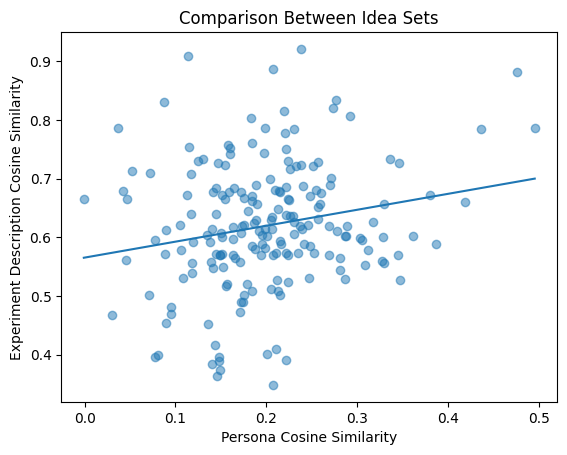

slope: 0.2714417451763243


In [16]:
# fit a line to the data
reg = LinearRegression().fit(persona_similarities_between_sets.reshape(-1, 1), baseline_similarities_between_sets)
plt.scatter(persona_similarities_between_sets, baseline_similarities_between_sets, label='Between Sets', alpha=0.5)
plt.plot(np.linspace(min(persona_similarities_between_sets), max(persona_similarities_between_sets), 100),
         reg.predict(np.linspace(min(persona_similarities_between_sets), max(persona_similarities_between_sets), 100).reshape(-1, 1)))
plt.xlabel('Persona Cosine Similarity')
plt.ylabel('Experiment Description Cosine Similarity')
plt.title('Comparison Between Idea Sets')
plt.show()
print("slope:", reg.coef_[0])

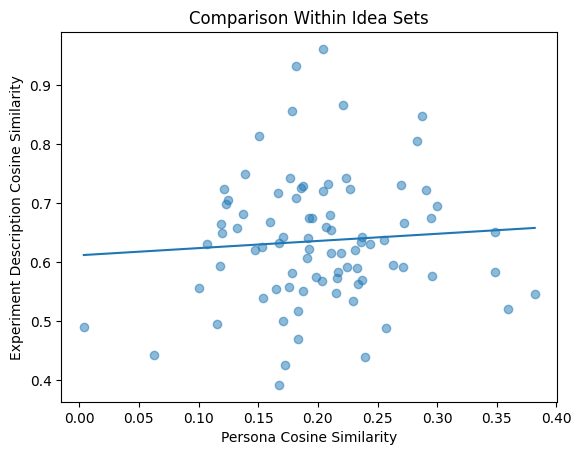

slope: 0.12144281472428214


In [17]:
reg = LinearRegression().fit(persona_similarities_within_sets.reshape(-1, 1), baseline_similarities_within_sets)
plt.scatter(persona_similarities_within_sets, baseline_similarities_within_sets, label='Within Sets', alpha=0.5)
plt.plot(np.linspace(min(persona_similarities_within_sets), max(persona_similarities_within_sets), 100),
         reg.predict(np.linspace(min(persona_similarities_within_sets), max(persona_similarities_within_sets), 100).reshape(-1, 1)))
plt.xlabel('Persona Cosine Similarity')
plt.ylabel('Experiment Description Cosine Similarity')
plt.title('Comparison Within Idea Sets')
plt.show()
print("slope:", reg.coef_[0])